# Notebook 4 — Revenue Regression Modelling

## Purpose
Frame revenue forecasting as a supervised regression problem.
Target variable: revenue_at_risk = MonthlyCharges × churn_probability

This is distinct from churn classification (binary output).
Here the model predicts a continuous dollar value per customer.

## Models Trained
- Linear Regression (baseline)
- Ridge Regression (regularised linear)
- Random Forest Regressor (ensemble)
- Gradient Boosting Regressor (sequential boosting)

## Key Output
Best regression model saved as models/best_regressor.pkl

In [1]:
# Cell 1 — Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Add project root to path so we can import from src/
sys.path.insert(0, os.path.abspath('..'))

from src.regressors  import (build_regression_target, train_regressors,
                              get_best_regressor, evaluate_regressor)
from src.utils       import save_model, set_random_seed

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']       = 120
plt.rcParams['figure.facecolor'] = 'white'

set_random_seed(42)

PROCESSED_PATH = '../data/processed/'
MODELS_PATH    = '../models/'
FIGURES_PATH   = '../reports/figures/'

print("Setup complete.")

Random seed set to 42
Setup complete.


In [1]:
import joblib
import sys
sys.path.insert(0, '..')

from src.regressors import train_regressors, get_best_regressor
import pandas as pd

X_train    = pd.read_csv('../data/processed/X_train.csv')
X_test     = pd.read_csv('../data/processed/X_test.csv')
y_train    = pd.read_csv('../data/processed/y_train.csv').squeeze()

# Reload OOF probabilities and build regression target
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np

df_clean = pd.read_csv('../data/processed/churn_cleaned.csv')
df_train_orig, _ = train_test_split(
    df_clean, test_size=0.2, random_state=42, stratify=df_clean['Churn']
)
df_train_orig = df_train_orig.reset_index(drop=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fresh_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
train_proba_oof = cross_val_predict(
    fresh_clf, X_train, y_train, cv=cv, method='predict_proba'
)[:, 1]

y_reg_train = pd.Series(
    df_train_orig['MonthlyCharges'].values * train_proba_oof,
    name='revenue_at_risk'
)

# Train regressors and save best
from src.regressors import train_regressors, get_best_regressor
reg_results = train_regressors(X_train, y_reg_train, cv_folds=5)
best_name, best_model = get_best_regressor(reg_results)

joblib.dump(best_model, '../models/best_regressor.pkl')
print(f"Saved: best_regressor.pkl — model: {best_name}")

Linear Regression              CV R²: 0.9614 ± 0.0007
Ridge Regression               CV R²: 0.9614 ± 0.0007
Random Forest Regressor        CV R²: 0.9769 ± 0.0022
Gradient Boosting Regressor    CV R²: 0.9932 ± 0.0006

Best regressor (by CV R²): Gradient Boosting Regressor
Saved: best_regressor.pkl — model: Gradient Boosting Regressor


In [2]:
# Load data

X_train  = pd.read_csv(f'{PROCESSED_PATH}X_train.csv')
X_test   = pd.read_csv(f'{PROCESSED_PATH}X_test.csv')
y_train  = pd.read_csv(f'{PROCESSED_PATH}y_train.csv').squeeze()
y_test   = pd.read_csv(f'{PROCESSED_PATH}y_test.csv').squeeze()
df_clean = pd.read_csv(f'{PROCESSED_PATH}churn_cleaned.csv')

# Load the best classifier (Logistic Regression)
best_clf = joblib.load(f'{MODELS_PATH}best_classifier.pkl')

print("Data loaded:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Classifier: {type(best_clf).__name__}")

Data loaded:
  X_train : (5625, 30)
  X_test  : (1407, 30)
  Classifier: LogisticRegression


In [3]:
# Reconstruct original MonthlyCharges for train and test sets

from sklearn.model_selection import train_test_split

_, df_test_orig = train_test_split(
    df_clean, test_size=0.2, random_state=42, stratify=df_clean['Churn']
)
df_train_orig, _ = train_test_split(
    df_clean, test_size=0.2, random_state=42, stratify=df_clean['Churn']
)

df_train_orig = df_train_orig.reset_index(drop=True)
df_test_orig  = df_test_orig.reset_index(drop=True)

print(f"Train original: {df_train_orig.shape}")
print(f"Test original : {df_test_orig.shape}")

Train original: (5625, 20)
Test original : (1407, 20)


In [4]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model    import LogisticRegression

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Reinstantiate a fresh classifier (must not be already fitted)
fresh_clf = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42
)

print("Generating out-of-fold churn probabilities for X_train...")
print("(Each row predicted by a model that never saw that row)")

# cross_val_predict with method='predict_proba' gives OOF probabilities
train_proba_oof = cross_val_predict(
    fresh_clf, X_train, y_train,
    cv     = cv_strategy,
    method = 'predict_proba'
)[:, 1]   # column 1 = probability of churn

# For X_test: standard predict_proba on the fully-trained classifier
best_clf.fit(X_train, y_train)   # ensure it is fitted on full train set
test_proba = best_clf.predict_proba(X_test)[:, 1]

print(f"\nOOF train proba — min: {train_proba_oof.min():.4f}  "
      f"max: {train_proba_oof.max():.4f}  "
      f"mean: {train_proba_oof.mean():.4f}")
print(f"Test     proba — min: {test_proba.min():.4f}  "
      f"max: {test_proba.max():.4f}  "
      f"mean: {test_proba.mean():.4f}")

# Build regression targets using the honest OOF probabilities
y_reg_train = build_regression_target(df_train_orig, train_proba_oof)
y_reg_test  = build_regression_target(df_test_orig,  test_proba)

print(f"\nRegression target built (out-of-fold):")
print(f"  Train — mean: ${y_reg_train.mean():.2f}  "
      f"std: ${y_reg_train.std():.2f}")
print(f"  Test  — mean: ${y_reg_test.mean():.2f}  "
      f"std: ${y_reg_test.std():.2f}")
print(f"\nTotal monthly revenue at risk (test): ${y_reg_test.sum():,.2f}")

Generating out-of-fold churn probabilities for X_train...
(Each row predicted by a model that never saw that row)

OOF train proba — min: 0.0029  max: 0.9414  mean: 0.4129
Test     proba — min: 0.0047  max: 0.9344  mean: 0.4213

Regression target built (out-of-fold):
  Train — mean: $30.13  std: $27.16
  Test  — mean: $30.42  std: $27.11

Total monthly revenue at risk (test): $42,802.57


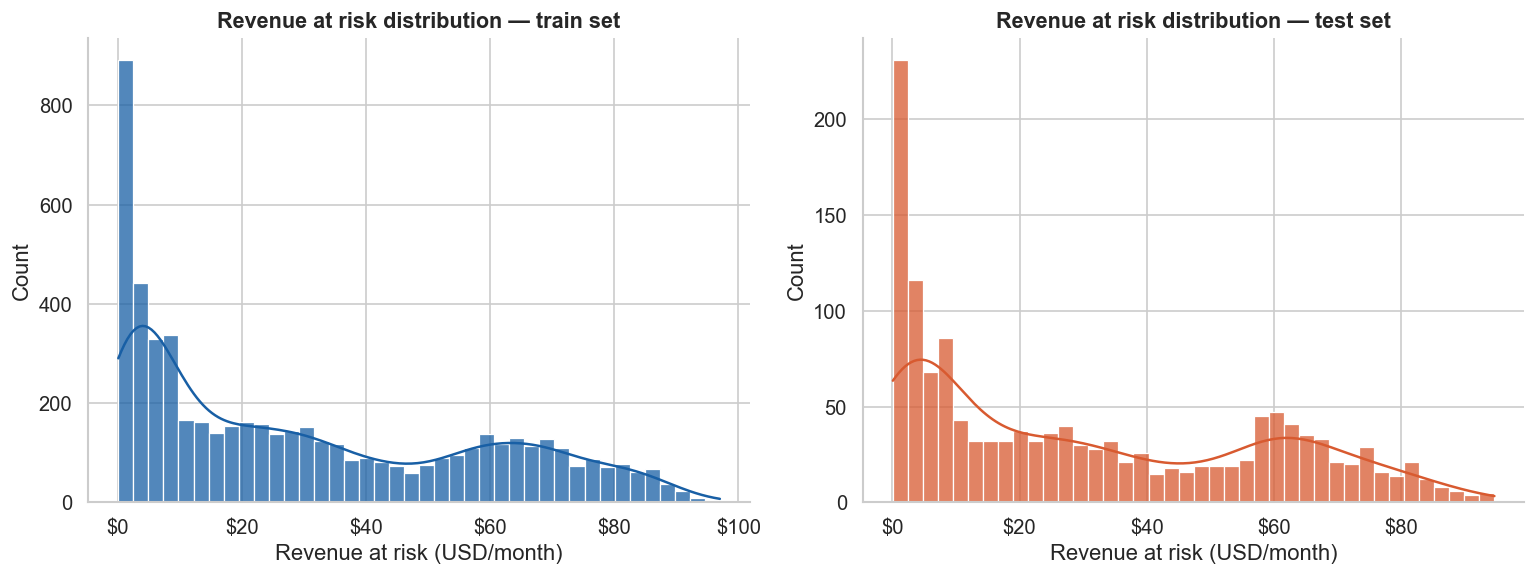

Saved: 20_regression_target_distribution.png


In [5]:
# Cell 5 — Visualise the regression target distribution


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Training set distribution
sns.histplot(y_reg_train, ax=axes[0], bins=40,
             color='#185FA5', alpha=0.75, kde=True)
axes[0].set_title('Revenue at risk distribution — train set',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue at risk (USD/month)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'${x:.0f}'))
sns.despine(ax=axes[0])

# Test set distribution
sns.histplot(y_reg_test, ax=axes[1], bins=40,
             color='#D85A30', alpha=0.75, kde=True)
axes[1].set_title('Revenue at risk distribution — test set',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue at risk (USD/month)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'${x:.0f}'))
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}20_regression_target_distribution.png',
            bbox_inches='tight')
plt.show()
print("Saved: 20_regression_target_distribution.png")

In [6]:
# Train all four regression models with 5-fold CV

print("Training regression models...")
print("=" * 60)

reg_results = train_regressors(X_train, y_reg_train, cv_folds=5)

print("=" * 60)
print("Training complete.")

Training regression models...
Linear Regression              CV R²: 0.9614 ± 0.0007
Ridge Regression               CV R²: 0.9614 ± 0.0007
Random Forest Regressor        CV R²: 0.9769 ± 0.0022
Gradient Boosting Regressor    CV R²: 0.9932 ± 0.0006
Training complete.


In [7]:
# Evaluate all models on the test set


test_results = []
for name, result in reg_results.items():
    metrics = evaluate_regressor(result['model'], X_test, y_reg_test)
    metrics['Model']      = name
    metrics['CV R² Mean'] = result['cv_r2'].mean()
    metrics['CV R² Std']  = result['cv_r2'].std()
    test_results.append(metrics)

test_df = (pd.DataFrame(test_results)
           .set_index('Model')
           .sort_values('R2', ascending=False))

print("=" * 65)
print("  REGRESSION RESULTS — TEST SET")
print("=" * 65)
print(test_df[['CV R² Mean','CV R² Std','MAE','RMSE','R2']].round(4).to_string())
print("=" * 65)

  REGRESSION RESULTS — TEST SET
                             CV R² Mean  CV R² Std     MAE    RMSE      R2
Model                                                                     
Gradient Boosting Regressor      0.9932     0.0006  1.2026  1.8067  0.9956
Random Forest Regressor          0.9769     0.0022  2.6015  3.9945  0.9783
Linear Regression                0.9614     0.0007  3.8798  5.1481  0.9639
Ridge Regression                 0.9614     0.0007  3.8798  5.1492  0.9639
